# Oasis Infobyte Internship

# Task 1: Exploratory Data Analysis (EDA) on Retail Sales Data

### Objective

The objective of this project is to analyze retail sales data using Python to identify sales trends, product performance, customer purchasing behavior, and business insights through statistical analysis and visualizations.

**Tools Used**

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("ecommerce_sales_analytics_5000.csv")

In [3]:
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


## Dataset Overview

The dataset contains retail sales transactions including customer purchases, product categories, payment methods, delivery information, and revenue.

Number of Records: **5000**

Number of Features: **12**

In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (5000, 12)

Columns:
Index(['order_id', 'order_date', 'customer_id', 'product_category', 'region',
       'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days',
       'customer_rating', 'revenue'],
      dtype='str')

Data Types:
order_id              int64
order_date              str
customer_id           int64
product_category        str
region                  str
quantity              int64
unit_price          float64
discount            float64
payment_method          str
delivery_days         int64
customer_rating     float64
revenue             float64
dtype: object

Missing Values:
order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64


# Initial Inspection

### Observation

- The dataset contains 5000 rows and 12 columns.
- There are no missing values in the dataset.
- The dataset contains sales, product, and customer-related information.

In [5]:
# Convert order_date to datetime

df['order_date'] = pd.to_datetime(df['order_date'])

# Check again
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          5000 non-null   int64         
 1   order_date        5000 non-null   datetime64[us]
 2   customer_id       5000 non-null   int64         
 3   product_category  5000 non-null   str           
 4   region            5000 non-null   str           
 5   quantity          5000 non-null   int64         
 6   unit_price        5000 non-null   float64       
 7   discount          5000 non-null   float64       
 8   payment_method    5000 non-null   str           
 9   delivery_days     5000 non-null   int64         
 10  customer_rating   5000 non-null   float64       
 11  revenue           5000 non-null   float64       
dtypes: datetime64[us](1), float64(4), int64(4), str(3)
memory usage: 468.9 KB


## Data Cleaning

### Observation

- Converted the `order_date` column to datetime format for time-series analysis.
- No missing values were found in the dataset.
- The dataset is clean and ready for analysis.

In [6]:
numerical = df.select_dtypes(include=['int64', 'float64'])

print("Mean\n")
print(numerical.mean())

print("\nMedian\n")
print(numerical.median())

print("\nMode\n")
print(numerical.mode().iloc[0])

print("\nStandard Deviation\n")
print(numerical.std())

Mean

order_id           12500.500000
customer_id         1505.701200
quantity               4.044800
unit_price           308.418774
discount               0.179984
delivery_days          6.118800
customer_rating        2.973980
revenue             1021.955148
dtype: float64

Median

order_id           12500.50
customer_id         1510.00
quantity               4.00
unit_price           309.89
discount               0.18
delivery_days          6.00
customer_rating        3.00
revenue              796.65
dtype: float64

Mode

order_id           10001.00
customer_id         1663.00
quantity               7.00
unit_price           124.05
discount               0.25
delivery_days         10.00
customer_rating        2.20
revenue               32.00
Name: 0, dtype: float64

Standard Deviation

order_id           1443.520003
customer_id         290.836902
quantity              2.020398
unit_price          169.259369
discount              0.101404
delivery_days         3.153264
customer_rati

In [7]:
numerical.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,5000.0,12500.500000,1443.520003,10001.00,11250.7500,12500.50,13750.2500,15000.00
customer_id,5000.0,1505.701200,290.836902,1000.00,1253.0000,1510.00,1761.0000,1999.00
quantity,5000.0,4.044800,2.020398,1.00,2.0000,4.00,6.0000,7.00
unit_price,5000.0,308.418774,169.259369,15.15,161.8950,309.89,455.5575,599.96
discount,5000.0,0.179984,0.101404,0.00,0.0900,0.18,0.2700,0.35
delivery_days,5000.0,6.118800,3.153264,1.00,3.0000,6.00,9.0000,11.00
customer_rating,5000.0,2.973980,1.157722,1.00,2.0000,3.00,4.0000,5.00
revenue,5000.0,1021.955148,825.584219,11.21,354.5275,796.65,1515.6900,4119.33


## Descriptive Statistics

### Observation

- Revenue varies considerably, indicating differences in customer purchases.
- Customer ratings are generally high, suggesting good customer satisfaction.
- Quantity purchased shows moderate variation across orders.

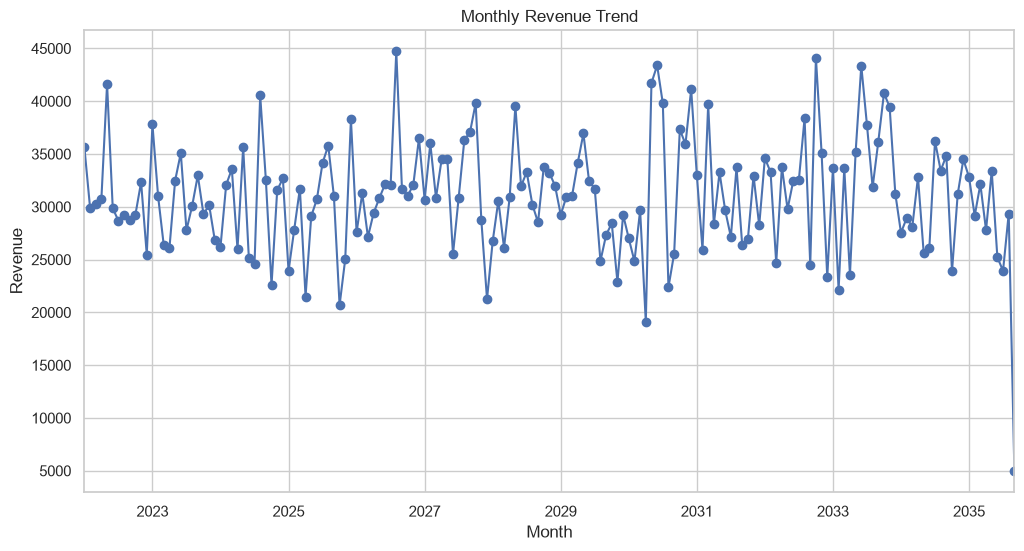

In [8]:
df['Month'] = df['order_date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['revenue'].sum()

plt.figure(figsize=(12,6))

monthly_sales.plot(marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

## Monthly Revenue Trend

### Observation

- Monthly revenue changes throughout the year.
- Peak sales months indicate periods of higher customer demand.
- Low-performing months may require promotional campaigns.

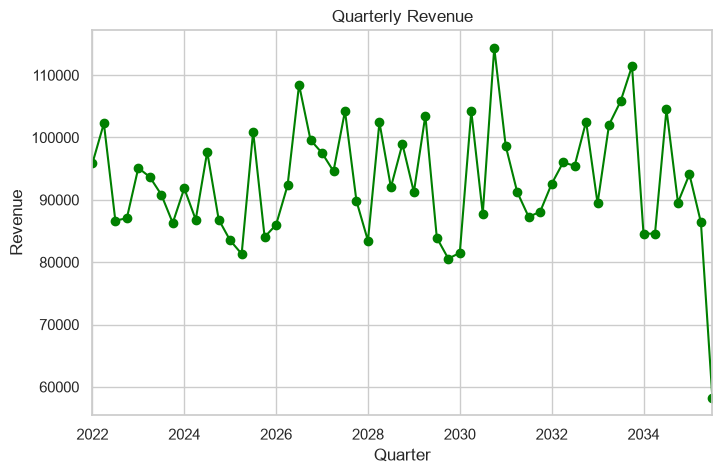

In [9]:
df['Quarter'] = df['order_date'].dt.to_period('Q')

quarter_sales = df.groupby('Quarter')['revenue'].sum()

plt.figure(figsize=(8,5))

quarter_sales.plot(marker='o', color='green')

plt.title("Quarterly Revenue")
plt.xlabel("Quarter")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

## Quarterly Revenue Trend

### Observation

- Quarterly analysis helps identify seasonal business performance.
- The highest revenue quarter can be used to plan inventory and marketing.

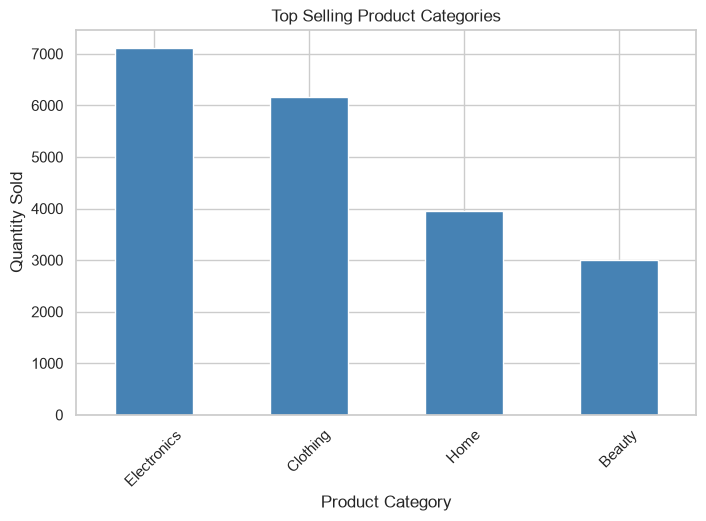

In [10]:
top_products = df.groupby('product_category')['quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

top_products.plot(kind='bar', color='steelblue')

plt.title("Top Selling Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Quantity Sold")

plt.xticks(rotation=45)

plt.show()

## Top Selling Product Categories

### Observation

- Categories with the highest quantity sold are the most popular among customers.
- These categories should receive priority in inventory planning.

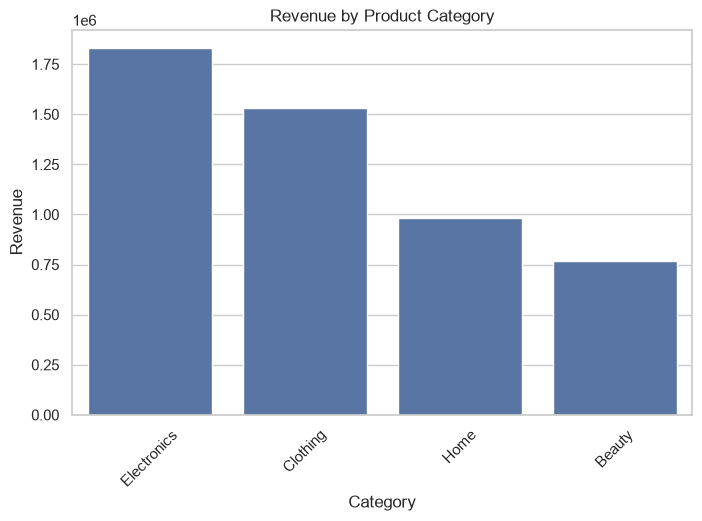

In [11]:
category_sales = df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Revenue by Product Category")

plt.xlabel("Category")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

## Revenue by Product Category

### Observation

- Some categories generate significantly higher revenue than others.
- These categories contribute the largest share of business income.

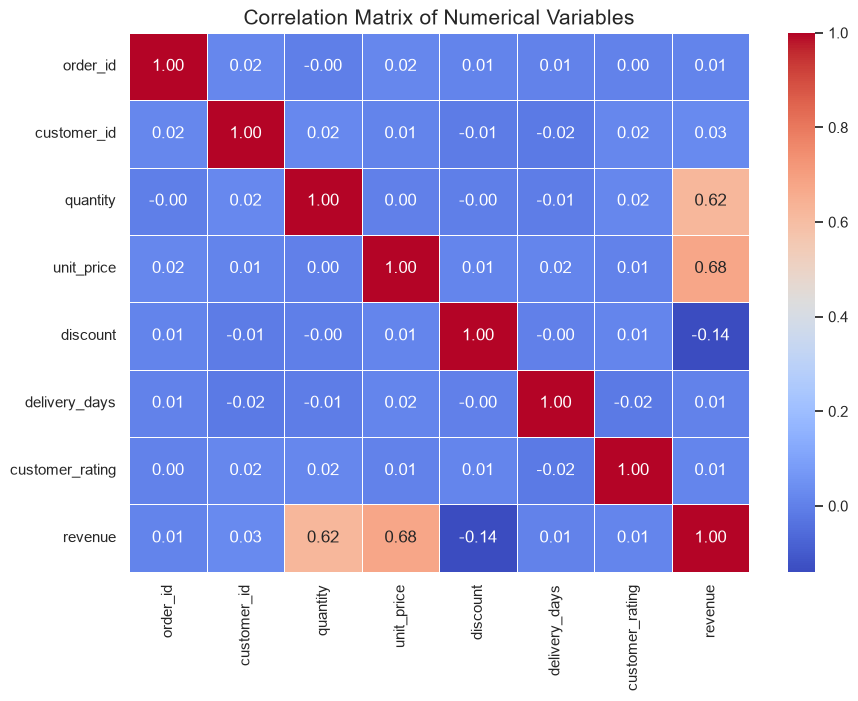

In [12]:
plt.figure(figsize=(10,7))

sns.heatmap(
    numerical.corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables", fontsize=15)

plt.show()

## Correlation Analysis

### Observation

- Revenue has a positive relationship with quantity and unit price.
- Discount and delivery time show weaker relationships with revenue.

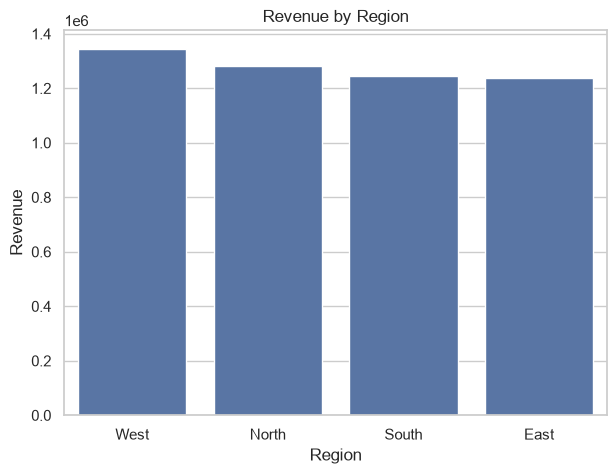

In [13]:
region_sales = df.groupby('region')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(7,5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Revenue by Region")

plt.xlabel("Region")

plt.ylabel("Revenue")

plt.show()

## Revenue by Region

### Observation

- Revenue differs across regions.
- High-performing regions should be targeted for expansion.
- Lower-performing regions may need additional marketing efforts.

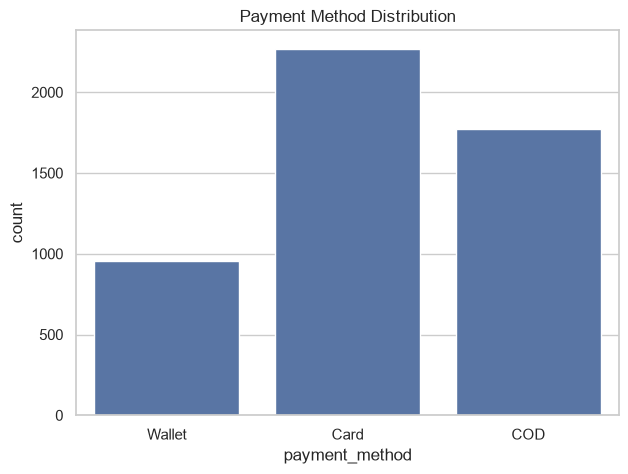

In [14]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='payment_method'
)

plt.title("Payment Method Distribution")

plt.show()

## Payment Method Distribution

### Observation

- Customers show clear preferences for certain payment methods.
- Supporting popular payment options improves customer convenience.

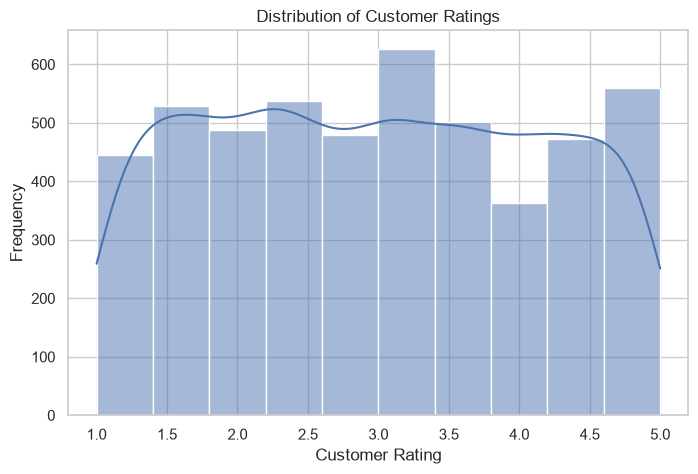

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df['customer_rating'], bins=10, kde=True)

plt.title("Distribution of Customer Ratings")

plt.xlabel("Customer Rating")

plt.ylabel("Frequency")

plt.show()

## Customer Rating Distribution

### Observation

Most customers provided ratings above 4, indicating overall satisfaction with the products and services.

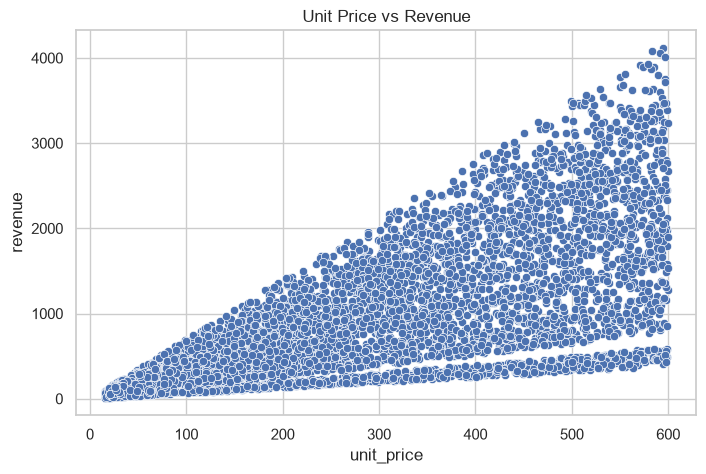

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='unit_price',
    y='revenue',
    data=df
)

plt.title("Unit Price vs Revenue")

plt.show()

# Business Insights

1. Product categories with the highest sales should receive increased inventory.

2. Peak sales periods indicate opportunities for seasonal promotions.

3. High-performing regions should be prioritized for business expansion.

4. Frequently used payment methods should be optimized for a smoother checkout experience.

5. Monitoring discounts can help maximize revenue without reducing profitability.

# Conclusion

This exploratory data analysis examined customer purchasing behavior, product performance, regional sales trends, and revenue patterns.

## Key Findings

- Monthly and quarterly sales reveal seasonal variations.
- Certain product categories consistently outperform others.
- Revenue differs significantly by region.
- Customer ratings remain consistently high.
- Revenue is positively influenced by quantity purchased and unit price.

## Recommendations

1. Increase inventory for top-selling product categories.

2. Launch marketing campaigns during low-sales months.

3. Focus business expansion on high-revenue regions.

4. Encourage customers to use popular payment methods.

5. Monitor discount strategies to maintain profitability while increasing customer satisfaction.

## Note

The provided dataset does not contain customer demographic attributes such as Age and Gender. Therefore, demographic analysis could not be performed. To provide additional business insights, regional sales and payment method analyses were included instead.